# Retake Exam 2024 - Risk based portfolio and

# Guided Solution


Below, I will examplify how to solve the problems. I will not, necessarily, provide the full solution. 

Results may depend on modelling choices. 

# Packages

Imported functions and modules are used for solving the exam.  

In [8]:
import os
from codelib.file_management.dynamic_file_pathing import get_root

root = get_root()
data_folder = os.path.join(root, "GBI Optimisation", "Data")

import sys
sys.path.insert(0,r"C:\Users\thorb\Documents\Github Repositories\AEF_thesis_GBI")

In [9]:
from typing import Union 

# numpy for working with matrices, etc. 
import numpy as np

# import pandas
import pandas as pd

# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import PercentFormatter


# scipy for statistics and optimization 
from scipy import optimize
from scipy import stats

# import cvxpy
import cvxpy as cp

# function to perform interpolation
from scipy.interpolate import interp1d

"""
functions from codelib
"""

# functions for calculating moments
from codelib.Johan.statistics import moments as mom

# functions for calculating risk metrics
from codelib.Johan.portfolio_optimization import risk_metrics as rm

# functions for risk budgetting
from codelib.Johan.portfolio_optimization import risk_metrics as rb

# functions for mean-variance optimization
from codelib.Johan.portfolio_optimization import mean_variance as mvo

# cash flows
from codelib.Johan.fixed_income.cash_flows import CashFlow

# predefined plots
from codelib.Johan.visualization.base import fan_chart

ModuleNotFoundError: No module named 'codelib.statistics'

# Problem 1: Portfolio optimization

Assume that the yearly linear return follows a log-normal distribution. The excel-file _data.xlsx_ contains the expected one year discrete return, the volatility and correlation of the one discrete return, and the yearly cost. 

In [5]:
"""
Load data
"""
data_path = os.path.join(data_folder, "Afkvastforventingerne.xlsx")

asset_names = pd.read_excel(data_path, sheet_name='Returns', index_col=0).index.values.flatten()
num_assets = len(asset_names)

asset_indices = {k: i for i, k in enumerate(asset_names)}

mu_linear_1y = pd.read_excel(data_path, sheet_name='Returns', index_col=0).values.flatten()

corr_mat_linear_1y = pd.read_excel(data_path, sheet_name='Correlation', index_col=0).values
corr_mat_linear_1y[np.tril_indices_from(corr_mat_linear_1y, k=-1)] = corr_mat_linear_1y.T[np.tril_indices_from(corr_mat_linear_1y, k=-1)]

vols_linear_1y = pd.read_excel(data_path, sheet_name='Volatility', index_col=0).values.flatten()
costs_linear_1y = pd.read_excel(data_path, sheet_name='Cost', index_col=0).values.flatten()

In [6]:
"""
Calculate covariance matrix
"""

cov_mat_linear_1y = mom.corr_to_cov_matrix(corr_mat_linear_1y, vols_linear_1y)

NameError: name 'mom' is not defined

In [21]:
pd.DataFrame(cov_mat_linear_1y)

,0,1,2,3,4,5,6,7,8,9
0,0.0010890000000000001,0.0011286,0.0006402000000000001,0.0012276000000000001,0.0,0.0,-0.0006732000000000001,-0.00048180000000000006,-0.00031680000000000006,0.0
1,0.0011286,0.003249,0.0038702999999999997,0.0031806,0.0027018,0.0035567999999999997,0.0023256,0.0008322,0.0005472000000000001,0.0015732
2,0.0006402000000000001,0.0038702999999999997,0.009409,0.0063146999999999995,0.0107282,0.0121056,0.009894,0.0056648,0.0027936000000000002,0.0053544
3,0.0012276000000000001,0.0031806,0.0063146999999999995,0.008649,0.007347,0.013540799999999999,0.0056916,0.0027156000000000003,0.0017856,0.004278
4,0.0,0.0027018,0.0107282,0.007347,0.024964,0.023004799999999995,0.022562399999999996,0.0092272,0.006067200000000001,0.010175199999999999
5,0.0,0.0035567999999999997,0.0121056,0.013540799999999999,0.023004799999999995,0.043264,0.025459199999999998,0.012147199999999999,0.0059904,0.0133952
6,-0.0006732000000000001,0.0023256,0.009894,0.0056916,0.022562399999999996,0.025459199999999998,0.04161599999999999,0.014891999999999997,0.007833600000000001,0.0112608
7,-0.00048180000000000006,0.0008322,0.0056648,0.0027156000000000003,0.0092272,0.012147199999999999,0.014891999999999997,0.021315999999999998,0.0042048,0.0040295999999999995
8,-0.00031680000000000006,0.0005472000000000001,0.0027936000000000002,0.0017856,0.006067200000000001,0.0059904,0.007833600000000001,0.0042048,0.009216,0.0026496
9,0.0,0.0015732,0.0053544,0.004278,0.010175199999999999,0.0133952,0.0112608,0.0040295999999999995,0.0026496,0.008464


## What is the $\mu$ and $\Sigma$ parameters in the log-normal distribution of the yearly log prices?

Assume discrete return after cost

We have that 

$$
E[1 + R] = e^{\mu + \frac{1}{2} \text{diag}(\Sigma)} - 1
$$

and 

$$
Cov[1 + R] = (e^{\Sigma} - I) \odot E[1 + R] E[1 + R]^\top
$$

From the latter, we can easily derive that 

$$
\Sigma   = \log ((Cov[1 + R] + E[1 + R] E[1 + R]^\top) \odot \frac{1}{E[1 + R] E[1 + R]^\top}) = \log (1 + Cov[1 + R] \odot \frac{1}{E[1 + R] E[1 + R]^\top})
$$

Knowing $\Sigma$, we can define 

$$
\mu = \log(E[1 + R]) - \frac{1}{2} \text{diag}(\Sigma)
$$

In [23]:
"""
Define function to convert between normal and log-normal parameters
"""

def convert_to_lognormal(mean, cov_mat): 

    cov_mat_log = np.log(1 + cov_mat / np.outer(mean, mean))
    
    mu_log = np.log(mean) - 0.5 * np.diag(cov_mat_log)

    return mu_log, cov_mat_log

In [24]:
mu_log_1y, cov_mat_log_1y = convert_to_lognormal(mean=1 + mu_linear_1y - costs_linear_1y, cov_mat=cov_mat_linear_1y)
vols_log_1y = np.sqrt(np.diag(cov_mat_log_1y))

In [25]:
cov_mat_log_1y

array([[ 0.00102795,  0.0010571 ,  0.00059236,  0.00113663,  0.        ,
         0.        , -0.00061867, -0.00044607, -0.00029693,  0.        ],
       [ 0.0010571 ,  0.00301673,  0.00354818,  0.00291958,  0.00243199,
         0.0031533 ,  0.00211784,  0.00076407,  0.00050872,  0.00147051],
       [ 0.00059236,  0.00354818,  0.00849803,  0.00571671,  0.00950361,
         0.0105602 ,  0.00886853,  0.00512547,  0.00256236,  0.00493439],
       [ 0.00113663,  0.00291958,  0.00571671,  0.00782913,  0.00652429,
         0.01181601,  0.00511616,  0.00246268,  0.00164011,  0.00394813],
       [ 0.        ,  0.00243199,  0.00950361,  0.00652429,  0.02157021,
         0.01960383,  0.01973808,  0.00818014,  0.00545307,  0.00918221],
       [ 0.        ,  0.0031533 ,  0.0105602 ,  0.01181601,  0.01960383,
         0.03602637,  0.02192011,  0.0105973 ,  0.00530511,  0.01189372],
       [-0.00061867,  0.00211784,  0.00886853,  0.00511616,  0.01973808,
         0.02192011,  0.03651737,  0.01332005

In [26]:
mu_log_1y

array([0.02807348, 0.03482356, 0.04454115, 0.04392276, 0.05687355,
       0.06448804, 0.0379326 , 0.03911826, 0.03206515, 0.02646588])

### Validate by simulations that the obtained parameters are consistent with provided expected returns, volatilities and covariance matrix

In [27]:
mom.calculate_log_norm_mean(mu_log_1y, cov_mat_log_1y) - 1.0 - (mu_linear_1y - costs_linear_1y)

array([-8.67361738e-17, -7.63278329e-17,  4.16333634e-17, -6.93889390e-17,
        5.55111512e-17,  8.32667268e-17,  7.63278329e-17,  5.55111512e-17,
        1.38777878e-16, -7.28583860e-17])

In [28]:
mom.calculate_log_norm_cov_mat(mu_log_1y, cov_mat_log_1y) - cov_mat_linear_1y

array([[-1.73472348e-18, -5.61616725e-17,  9.63855731e-17,
         1.53956708e-17,  0.00000000e+00,  0.00000000e+00,
        -2.23345648e-17, -5.39932682e-17, -4.03865309e-17,
         0.00000000e+00],
       [-5.61616725e-17,  8.45677695e-17, -6.89552582e-17,
        -7.67615138e-17,  8.15320034e-17,  1.82145965e-17,
         3.16587034e-17,  1.45283091e-17,  5.95226993e-17,
        -3.88144378e-17],
       [ 9.63855731e-17, -6.89552582e-17, -1.05818132e-16,
        -1.10154941e-16,  4.85722573e-17, -7.97972799e-17,
         1.02348685e-16, -4.85722573e-17, -8.93382590e-17,
         4.59701721e-17],
       [ 1.53956708e-17, -7.67615138e-17, -1.10154941e-16,
        -9.88792381e-17,  4.25007252e-17,  3.46944695e-17,
        -1.13624388e-16, -7.41594286e-17,  3.79470760e-17,
        -7.80625564e-18],
       [ 0.00000000e+00,  8.15320034e-17,  4.85722573e-17,
         4.25007252e-17, -8.67361738e-17,  4.16333634e-17,
        -4.16333634e-17,  5.37764278e-17, -9.36750677e-17,
        -8.

In [29]:
"""
Simulation - choose an asset index
"""

asset_idx = 0
num_sim = 100_000

sim_log_norm_1y = stats.lognorm(s=vols_log_1y[asset_idx], scale=np.exp(mu_log_1y[asset_idx])).rvs(num_sim) - 1.0

In [30]:
sim_log_norm_1y.mean()

0.028971068540465373

In [31]:
mu_linear_1y - costs_linear_1y

array([0.029 , 0.037 , 0.05  , 0.049 , 0.07  , 0.086 , 0.0578, 0.0499,
       0.037 , 0.0309])

### Weekly parameters

Assume independence. 

Since log-returns aggregrate across time, we can simply multiply with the time step. 

In [32]:
"""
Weekly parameters
"""

# time step 
dt = 1.0 / 52.0 

# Calculate weekly parameters of the log-normal distribution
mu_log_weekly, cov_mat_log_weekly = mu_log_1y * dt, cov_mat_log_1y * dt
vols_log_weekly = np.sqrt(np.diag(cov_mat_log_weekly))

## Simulate the log-returns and prices for the next 10 years

In [33]:
def simulate_price_evolution(initial_values: np.ndarray,
               mu: np.ndarray, 
               cov_mat: np.ndarray,
               num_sim: int, 
               num_per: int):
    
    # number of risk drivers
    num_risk_drivers = len(mu)
    
    # define matrix to store values
    risk_drivers = np.zeros((num_sim, 1 + num_per, num_risk_drivers))
    risk_drivers[:, 0, :] = np.log(initial_values)
    
    # simulate normal invariants
    eps = stats.multivariate_normal(mean=mu, cov=cov_mat).rvs(size=(num_sim, num_per))
    
    # create risk drives at horizon
    risk_drivers[:, 1:, :] = np.log(initial_values) + np.cumsum(eps, axis=1)
    
    return np.exp(risk_drivers)

In [34]:
def calculate_analytical_percentile(mu: np.ndarray,
                                    vol: np.ndarray, 
                                    horizon=1.0,
                                    q=0.5) -> float: 
    """
    Function calculating the q-percentile of a constant-mix portfolio. 
    """
    
    if horizon == 0.0:
        return np.ones_like(q)
    else: 
        return stats.lognorm.ppf(q, s=vol * np.sqrt(horizon), scale=np.exp(mu * horizon))

In [35]:
"""
Inputs
"""

num_sim = 100_000
num_per = 52 * 5

"""
Simulate prices
"""
time_points = np.arange(0, 5 + dt, dt)
sim_prices = simulate_price_evolution(np.ones_like(asset_names, dtype=float), mu_log_weekly, cov_mat_log_weekly, num_sim, num_per)

"""
Store in dict
"""

sim_data = {asset_names[i] : sim_prices[:, :, i] for i in range(num_assets)}

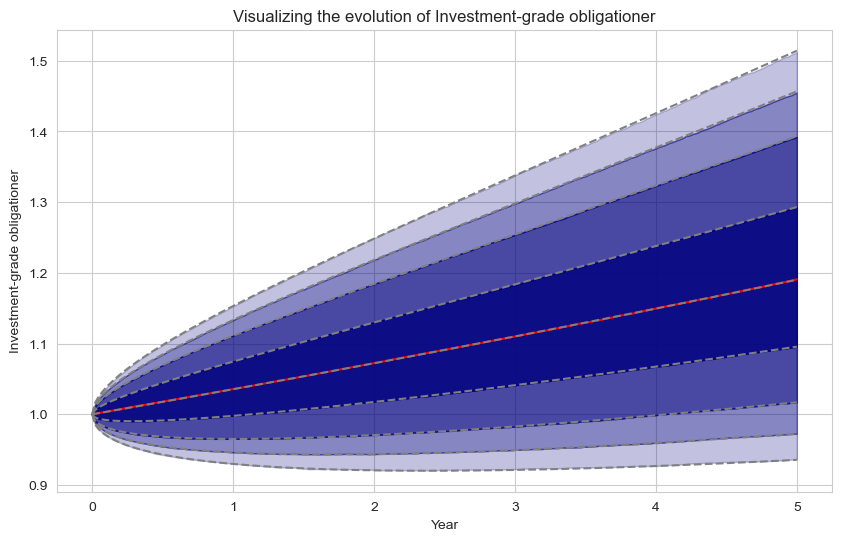

In [37]:
asset_id = 'Investment-grade obligationer'
asset_idx = asset_indices[asset_id]

# calculate simulated percentiles for log-fx
percentiles = np.percentile(sim_data[asset_id], [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)
# calculating analytical percentiles
true_percentiles = np.array([calculate_analytical_percentile(mu_log_weekly[asset_idx], vols_log_weekly[asset_idx], t,
                             q=[0.025, 0.05 , 0.1  , 0.25 , 0.5  , 0.75 , 0.9  , 0.95 , 0.975]) for t in time_points / dt])

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")
ax.plot(time_points, true_percentiles, color="gray", linestyle="--");

ax.set(ylabel=asset_id, xlabel="Year", title="Visualizing the evolution of " + asset_id); 

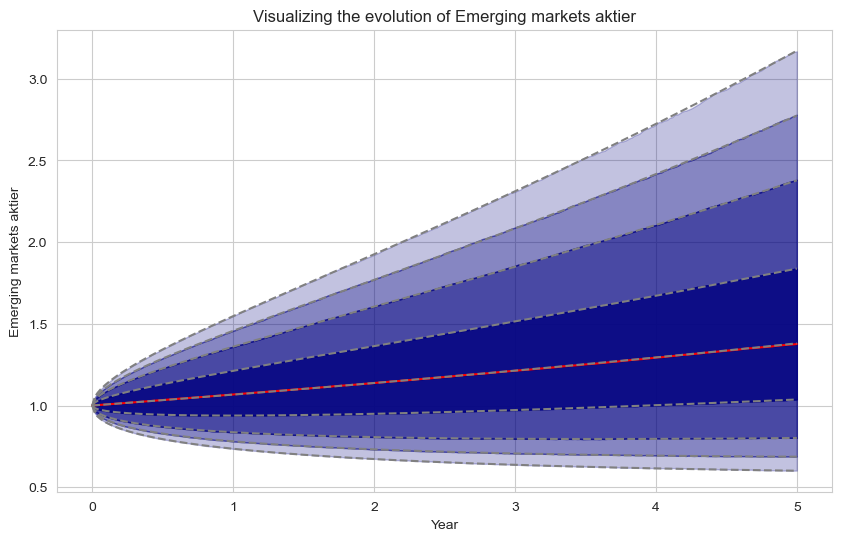

In [38]:
asset_id = 'Emerging markets aktier'
asset_idx = asset_indices[asset_id]

# calculate simulated percentiles for log-fx
percentiles = np.percentile(sim_data[asset_id], [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)
# calculating analytical percentiles
true_percentiles = np.array([calculate_analytical_percentile(mu_log_weekly[asset_idx], vols_log_weekly[asset_idx], t,
                             q=[0.025, 0.05 , 0.1  , 0.25 , 0.5  , 0.75 , 0.9  , 0.95 , 0.975]) for t in time_points / dt])

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")
ax.plot(time_points, true_percentiles, color="gray", linestyle="--");

ax.set(ylabel=asset_id, xlabel="Year", title="Visualizing the evolution of " + asset_id); 

## Calculate risk measures for the assets on a weekly and yearly horizon

We provide the mean, standard deviation, skewness, kurtosis (excess), VaR and CVaR

In [39]:
def calculate_analytical_metrics(mu, vol, alpha=0.05):
        
    dict = {}
    
    dist = stats.lognorm(s=vol, scale=np.exp(mu), loc=-1)

    mean, var, skew, kurt = dist.stats(moments='mvsk')
    std = np.sqrt(var)

    # Value at Risk
    VaR = -1 * dist.ppf(0.05)

    # Conditional Value at Risk
    CVaR = -((np.exp(mu + vol**2 / 2) * stats.norm.cdf(stats.norm.ppf(alpha) - vol)) / alpha - 1)
    
    return {
        'Expected value': mean,
         'Standard deviation': std,
         'Kurtosis': kurt, 
         'Skewness': skew, 
         'VaR({}%)'.format(alpha*100): VaR, 
         'CVaR({}%)'.format(alpha*100): CVaR, 
         'IR': mean / std}

### Weekly horizon

In [40]:
results_weekly = []

for asset, mu, vol in zip(asset_names, mu_log_weekly, vols_log_weekly): 

    metrics = calculate_analytical_metrics(mu, vol)
    metrics['Asset'] = asset

    results_weekly.append(metrics)

df_metrics_weekly = pd.DataFrame(results_weekly).set_index('Asset')

In [41]:
df_metrics_weekly * 100

,Expected value,Standard deviation,Kurtosis,Skewness,VaR(5.0%),CVaR(5.0%),IR
Asset,,,,,,,
Stats- og realkreditobligationer,0.05499099306716104,0.44486288965572857,0.03163026817558645,1.33386395822522,0.6750523113882467,0.8592786020373944,12.361335221671915
Investment-grade obligationer,0.06989350884414325,0.7622133373929791,0.0928303133220787,2.2850871050302217,1.178863456705892,1.4924882745440127,9.169809214202692
High-yield obligationer,0.09387127031117437,1.2796248883340966,0.26153927120216025,3.8354833860789603,1.9968727631885508,2.517892548826839,7.335842805728984
Emerging markets statsobligationer,0.09203719251220654,1.2282055971557295,0.2409485818913204,3.681413454769855,1.9152396571307517,2.4158463691587584,7.493630767140752
Globale aktier (developed markets),0.13019746893536688,2.0395557652443586,0.6640945666783082,6.111556410961407,3.188741249738336,4.006419224579227,6.3836189798795715
Emerging markets aktier,0.15878212074369458,2.6367736031744795,1.109608466058809,7.899605077815417,4.118262547324624,5.162537539036194,6.0218336740224006
Private equity,0.10811855919208302,2.6533442231321276,1.1247463339612906,7.953297662588016,4.195388555614931,5.245840164631099,4.074803346263719
Infrastruktur,0.09368793964030786,1.9211756216487414,0.5896451433399008,5.758839290009686,3.0345801434405906,3.806652442549918,4.8765942366010995
Ejendomme,0.06989350884414325,1.2819907194777114,0.2626332397726472,3.8434962050580874,2.024686376484719,2.5466410615469393,5.451951233517366


In [42]:
"""
Covariance matrix and expectation vector 
"""

mu_l_weekly = mom.calculate_log_norm_mean(mu_log_weekly, cov_mat_log_weekly) - 1.0
cov_mat_l_weekly = mom.calculate_log_norm_cov_mat(mu_log_weekly, cov_mat_log_weekly)

In [43]:
mu_l_weekly

array([0.00054991, 0.00069894, 0.00093871, 0.00092037, 0.00130197,
       0.00158782, 0.00108119, 0.00093688, 0.00069894, 0.00058541])

### Yearly horizon

In [44]:
results_1y = []

for asset, mu, vol in zip(asset_names, mu_log_1y, vols_log_1y): 

    metrics = calculate_analytical_metrics(mu, vol)
    metrics['Asset'] = asset

    results_1y.append(metrics)

df_metrics_1y = pd.DataFrame(results_1y).set_index('Asset')

In [45]:
df_metrics_1y * 100

,Expected value,Standard deviation,Kurtosis,Skewness,VaR(5.0%),CVaR(5.0%),IR
Asset,,,,,,,
Stats- og realkreditobligationer,2.8999999999999915,3.299999999999997,1.647160166918038,9.624289595723122,2.436171665311926,3.727753215899643,87.87878787878769
Investment-grade obligationer,3.699999999999992,5.700000000000075,4.847770442498867,16.506481527953284,5.400660597115447,7.528002428322189,64.9122807017534
High-yield obligationer,5.000000000000004,9.699999999999946,13.764407944743517,27.79312583954201,10.155454756510773,13.5005844580939,51.54639175257765
Emerging markets statsobligationer,4.899999999999993,9.299999999999946,12.66873705800231,26.666441102536165,9.662526765044866,12.895276051280158,52.68817204301099
Globale aktier (developed markets),7.000000000000006,15.799999999999972,35.606637601862005,44.62103877170018,16.864867237940516,21.69999965453452,44.303797468354546
Emerging markets aktier,8.600000000000009,20.799999999999976,60.741376536893995,58.16115121435532,21.941783983662823,27.720056571264074,41.34615384615393
Private equity,5.779999999999985,20.400000000000023,61.61366566835254,58.57319268536493,24.148370043712053,29.798860394258565,28.333333333333226
Infrastruktur,4.990000000000028,14.59999999999998,31.505963591654407,41.98717371614517,17.181782017641844,21.734412701409266,34.17808219178106
Ejendomme,3.7000000000000144,9.600000000000026,13.82267809072708,27.851757746041383,11.297490286177181,14.606765764516705,38.54166666666671


In [46]:
"""
Covariance matrix and expectation vector 
"""

mu_l_1y = mom.calculate_log_norm_mean(mu_log_1y, cov_mat_log_1y) - 1.0
cov_mat_l_1y = mom.calculate_log_norm_cov_mat(mu_log_1y, cov_mat_log_1y)

## Calculate risk measures for three different portfolios at weekly and yearly horizon

### Define portfolios

In [47]:
"""
Equally weighted portfolio
"""

w_eq = np.ones(num_assets) / num_assets

In [48]:
"""
Minimum variance portfolios
"""

def calculate_min_var_portfolio(cov_mat: np.ndarray): 
        
    # define target variable
    num_assets = cov_mat.shape[0]
    w = cp.Variable(num_assets)
    
    # define constraints
    constraints = [cp.sum(w) == 1.0, w>=0]
    
    # define problem 
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cov_mat)), constraints)
    
    # solve
    prob.solve()
    
    if prob.status == 'optimal':
        return w.value
    else:    
        return np.ones(num_assets) * np.nan

# minimum variance portfolio (weekly)
w_min_var_weekly = calculate_min_var_portfolio(cov_mat_l_weekly) 

# minimum variance portfolio (yearly)
w_min_var_1y = calculate_min_var_portfolio(cov_mat_l_1y)

In [49]:
pd.DataFrame(w_min_var_weekly, index=asset_names)

,0
Stats- og realkreditobligationer,0.8194637120393023
Investment-grade obligationer,-1.2015737125389406e-17
High-yield obligationer,3.3942247331082846e-19
Emerging markets statsobligationer,-4.864352629028505e-18
Globale aktier (developed markets),1.6687771769627104e-17
Emerging markets aktier,2.2683390462098928e-17
Private equity,2.2912029986757235e-17
Infrastruktur,0.03125572681314892
Ejendomme,0.09148307497192508
Hedgefonde,0.057797486175623664


In [50]:
pd.DataFrame(w_min_var_1y, index=asset_names)

,0
Stats- og realkreditobligationer,0.8216949166927414
Investment-grade obligationer,-3.9946882178467945e-21
High-yield obligationer,1.946856332894645e-22
Emerging markets statsobligationer,-1.5596190031486587e-21
Globale aktier (developed markets),5.945232628038681e-21
Emerging markets aktier,8.231792911316129e-21
Private equity,7.935945980773435e-21
Infrastruktur,0.029701738198404017
Ejendomme,0.09039387558775232
Hedgefonde,0.05820946952110221


In [51]:
"""
Max Sharpe - old
"""

def calculate_max_sharpe_portfolio(mu, cov_mat, rf=0): 

    # negative sharpe ratio
    neg_sharpe_ratio = lambda w: -(mvo.portfolio_mean(w, mu) - rf) / mvo.portfolio_std(w, cov_mat)

    # constraints and bounds
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0.0, 1.0) for _ in range(len(mu))]

    # starting values
    w0 = np.ones(len(mu)) / len(mu)

    # minimize negative sharpe ratio
    res = optimize.minimize(neg_sharpe_ratio, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    
    return res.x

def calculate_mean_var_portfolio(mu: np.ndarray, cov_mat: np.ndarray, target): 
        
    # define target variable
    num_assets = cov_mat.shape[0]
    w = cp.Variable(num_assets)
    
    # define constraints
    constraints = [cp.sum(w) == 1.0, w>=0, w @ mu == target]
    
    # define problem 
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cov_mat)), constraints)
    
    # solve
    prob.solve()
    
    if prob.status == 'optimal':
        return w.value
    else:    
        return np.ones(num_assets) * np.nan

# low
w_mvo_low = calculate_mean_var_portfolio(mu_l_1y, cov_mat_l_1y, 0.035)

# medium
w_mvo_medium = calculate_mean_var_portfolio(mu_l_1y, cov_mat_l_1y, 0.045)

# high
w_mvo_high = calculate_mean_var_portfolio(mu_l_1y, cov_mat_l_1y, 0.065)

In [52]:
pd.DataFrame(w_mvo_low, index=asset_names)

,0
Stats- og realkreditobligationer,0.7782948419267441
Investment-grade obligationer,0.0022802943968876187
High-yield obligationer,1.2856602533105925e-19
Emerging markets statsobligationer,2.095401936260117e-20
Globale aktier (developed markets),0.0468949318412583
Emerging markets aktier,0.041598343770844565
Private equity,-1.2495445625479122e-20
Infrastruktur,0.04965171626985214
Ejendomme,0.0812798717944133
Hedgefonde,-1.0701845945573468e-19


In [53]:
pd.DataFrame(w_mvo_medium, index=asset_names)

,0
Stats- og realkreditobligationer,0.4581724324905036
Investment-grade obligationer,0.1906886901985249
High-yield obligationer,4.5699891813649156e-20
Emerging markets statsobligationer,7.246317299374347e-21
Globale aktier (developed markets),0.13610844342087228
Emerging markets aktier,0.12970558797210507
Private equity,-4.294126330670476e-21
Infrastruktur,0.06342845088388564
Ejendomme,0.021896395034108406
Hedgefonde,-3.8330747682145653e-20


In [54]:
pd.DataFrame(w_mvo_high, index=asset_names)

,0
Stats- og realkreditobligationer,-7.002333505602302e-21
Investment-grade obligationer,0.2568074046125488
High-yield obligationer,-1.7860793106858135e-21
Emerging markets statsobligationer,0.03533131194564445
Globale aktier (developed markets),0.31423002505396014
Emerging markets aktier,0.3359720276085409
Private equity,-1.456364217549962e-20
Infrastruktur,0.057659230779305785
Ejendomme,-5.433254540296191e-21
Hedgefonde,-1.0014246010379421e-20


### Calculate performance and risk metrics

In [55]:
ret_mat_weekly = sim_prices[:, 1, :] - 1.0
ret_mat_1y = sim_prices[:, 52, :] - 1.0

In [60]:
def calculate_portfolio_metrics(w, mu, cov_mat, ret_mat, asset_names=asset_names, alpha=0.05, use_analytical=False):

    # number of assets
    num_assets = len(w)

    # calculate portfolio return 
    port_ret = ret_mat @ w
    
    # Create data frame
    columns = [("Exposure", "Portfolio weights"),
               ("CVaR(5%)", "Standalone"), ("CVaR(5%)", "RC"), ("CVaR(5%)", "MR"),
               ("Expected return", "Standalone"), ("Expected return", "Contribution"),
               ("Std.", "Standalone"), ("Std.", "RC"), ("Std.", "MR"),
               ("Risk-Return", "RoRAC CVaR(5%)"), ("Risk-Return", "RoRAC Std."), 
               #("Risk-Return", "RoMR CVaR(5%)"), ("Risk-Return", "RoMR Std."), 
               ("Risk-Return", "IR CVaR(5%)"), ("Risk-Return", "IR Std.")] # ("Risk-Return", "DI"), 
    
    multi_index = pd.MultiIndex.from_tuples(columns, names=["Category", "Subcategory"])
    
    df_res = pd.DataFrame(columns=multi_index, index=pd.Index(['Portfolio'] + list(asset_names)))

    # exposure
    df_res.loc[:, ('Exposure','Portfolio weights')] = np.r_[1.0, w]

    # CVaR
    df_res.loc['Portfolio', ("CVaR(5%)", "Standalone")] = -rm.calculate_conditional_value_at_risk(port_ret, p=0.05)
    df_res.loc[asset_names, ("CVaR(5%)", "Standalone")] = [-rm.calculate_conditional_value_at_risk(ret_mat[:, i], p=0.05) for i in range(num_assets)]

    df_res.loc[asset_names, ("CVaR(5%)", "RC")] = -rb.calculate_risk_contributions_cvar(w, ret_mat)
    df_res.loc['Portfolio', ("CVaR(5%)", "RC")] = df_res.loc['Portfolio', ("CVaR(5%)", "Standalone")]
    
    df_res.loc[asset_names, ("CVaR(5%)", "MR")] = -rb.calculate_marginal_risks_cvar(w, ret_mat)

    # expected return 
    if use_analytical: 
        df_res.loc[asset_names, ("Expected return", "Standalone")] = mu
        df_res.loc['Portfolio', ("Expected return", "Standalone")] = w @ mu

        df_res.loc[asset_names, ("Expected return", "Contribution")] = mu * w
        df_res.loc['Portfolio', ("Expected return", "Contribution")] = w @ mu
    else: 
        mean_ret = np.mean(ret_mat, axis=0)
        
        df_res.loc[asset_names, ("Expected return", "Standalone")] = mean_ret
        df_res.loc['Portfolio', ("Expected return", "Standalone")] = np.mean(port_ret)

        df_res.loc[asset_names, ("Expected return", "Contribution")] = mean_ret * w
        df_res.loc['Portfolio', ("Expected return", "Contribution")] = np.mean(port_ret)

    # standard devation
    if use_analytical: 
        df_res.loc[asset_names, ("Std.", "Standalone")] = np.sqrt(np.diag(cov_mat))
        df_res.loc['Portfolio', ("Std.", "Standalone")] = np.sqrt(w @ cov_mat @ w)

        df_res.loc[asset_names, ("Std.", "RC")] = rb.calculate_risk_contributions_std(w, cov_mat)
        df_res.loc['Portfolio', ("Std.", "RC")] = np.sqrt(w @ cov_mat @ w)

        df_res.loc[asset_names, ("Std.", "MR")] = rb.calculate_marginal_risks_std(w, cov_mat)
    
    else: 
        cov_mat_est = np.cov(ret_mat.T)
        
        df_res.loc[asset_names, ("Std.", "Standalone")] = np.sqrt(np.diag(cov_mat_est))
        df_res.loc['Portfolio', ("Std.", "Standalone")] = np.sqrt(w @ cov_mat_est @ w)

        df_res.loc[asset_names, ("Std.", "RC")] = rb.calculate_marginal_risks_std(w, cov_mat_est)
        df_res.loc['Portfolio', ("Std.", "RC")] = np.sqrt(w @ cov_mat_est @ w)

        df_res.loc[asset_names, ("Std.", "MR")] = rb.calculate_risk_contributions_std(w, cov_mat_est)

    # risk-return 
    df_res.loc[:, ("Risk-Return", "RoRAC CVaR(5%)")] = df_res.loc[:, ("Expected return", "Contribution")] / df_res.loc[:, ("CVaR(5%)", "RC")]
    df_res.loc[:, ("Risk-Return", "RoRAC Std.")] = df_res.loc[:, ("Expected return", "Contribution")] / df_res.loc[:, ("Std.", "RC")]

    #df_res.loc[asset_names, ("Risk-Return", "RoMR CVaR(5%)")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("CVaR(5%)", "MR")]
    #df_res.loc[asset_names, ("Risk-Return", "RoMR Std.")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("Std.", "MR")]
    
    df_res.loc[:, ("Risk-Return", "IR CVaR(5%)")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("CVaR(5%)", "Standalone")]
    df_res.loc[:, ("Risk-Return", "IR Std.")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("Std.", "Standalone")]

    # df_res.loc[asset_names, ("Expected return", "Contribution")] / df_res.loc[asset_names, ("Expected return", "Contribution")]
    
    return df_res

In [61]:
"""
Equally weighted portfolio
"""

df_port_metrics_eq = calculate_portfolio_metrics(w_eq, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_eq

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

In [58]:
"""
Minimum variance portfolio
"""

df_port_metrics_min_var = calculate_portfolio_metrics(w_min_var_1y, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_min_var

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

In [130]:
df_port_metrics_low = calculate_portfolio_metrics(w_mvo_low, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_low

Category                              Exposure   CVaR(5%)                      \
Subcategory                  Portfolio weights Standalone        RC        MR   
Portfolio                                  1.0   0.028649  0.028649       NaN   
Government bonds                      0.716873   0.038671  0.013517  0.018856   
Investment-grade bonds                    -0.0   0.081452      -0.0  0.040697   
High-yield bonds                          -0.0   0.142576      -0.0  0.069975   
Emerging markets gov. bonds               -0.0   0.135363      -0.0  0.068015   
Equities (developed markets)               0.0   0.223825       0.0  0.094507   
Equities (Emerging markets)                0.0    0.28597       0.0  0.110609   
Private equity                        0.021361   0.268674  0.002051  0.095995   
Infrastructure                        0.068404   0.203775  0.004556  0.066608   
Real Estate                           0.103815   0.139708  0.004311   0.04153   
Hedgefunds                            0.089548    0.12897  0.004213  0.047049   

Category                     Expected return                    Std.  \
Subcategory                       Standalone Contribution Standalone   
Portfolio                              0.035        0.035   0.031784   
Government bonds                      0.0277     0.019857      0.033   
Investment-grade bonds                0.0307         -0.0      0.057   
High-yield bonds                       0.042         -0.0      0.097   
Emerging markets gov. bonds           0.0426         -0.0      0.093   
Equities (developed markets)          0.0631          0.0      0.158   
Equities (Emerging markets)           0.0769          0.0      0.208   
Private equity                        0.0877     0.001873      0.204   
Infrastructure                        0.0637     0.004357      0.146   
Real Estate                           0.0447     0.004641      0.096   
Hedgefunds                            0.0477     0.004271      0.092   

Category                                            Risk-Return             \
Subcategory                         RC        MR RoRAC CVaR(5%) RoRAC Std.   
Portfolio                     0.031784       NaN       1.221704   1.101175   
Government bonds              0.015798  0.022038       1.469049   1.256941   
Investment-grade bonds            -0.0  0.035028       0.754361   0.876432   
High-yield bonds                  -0.0   0.05749       0.600215   0.730563   
Emerging markets gov. bonds       -0.0  0.055242       0.626329   0.771152   
Equities (developed markets)       0.0  0.083506       0.667672   0.755637   
Equities (Emerging markets)        0.0  0.100558       0.695241   0.764734   
Private equity                0.002182  0.102147       0.913585   0.858569   
Infrastructure                0.004795  0.070103       0.956349   0.908662   
Real Estate                   0.004644  0.044735       1.076331   0.999213   
Hedgefunds                    0.004365  0.048741       1.013832   0.978649   

Category                                            
Subcategory                  IR CVaR(5%)   IR Std.  
Portfolio                       1.221704  1.101175  
Government bonds                0.716298  0.839394  
Investment-grade bonds          0.376909  0.538596  
High-yield bonds                0.294579   0.43299  
Emerging markets gov. bonds     0.314709  0.458065  
Equities (developed markets)    0.281916  0.399367  
Equities (Emerging markets)     0.268909  0.369712  
Private equity                  0.326418  0.429902  
Infrastructure                    0.3126  0.436301  
Real Estate                     0.319953  0.465625  
Hedgefunds                      0.369853  0.518478

In [131]:
df_port_metrics_medium = calculate_portfolio_metrics(w_mvo_medium, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_medium

Category                              Exposure   CVaR(5%)                      \
Subcategory                  Portfolio weights Standalone        RC        MR   
Portfolio                                  1.0   0.057266  0.057266       NaN   
Government bonds                      0.497461   0.038671 -0.005297 -0.010648   
Investment-grade bonds                    -0.0   0.081452      -0.0   0.01949   
High-yield bonds                          -0.0   0.142576      -0.0  0.083773   
Emerging markets gov. bonds               -0.0   0.135363      -0.0  0.056171   
Equities (developed markets)               0.0   0.223825       0.0  0.151462   
Equities (Emerging markets)           0.021039    0.28597   0.00379  0.180149   
Private equity                        0.118162   0.268674  0.025116  0.212556   
Infrastructure                        0.142449   0.203775  0.018838  0.132247   
Real Estate                           0.123601   0.139708  0.007693   0.06224   
Hedgefunds                            0.097288    0.12897  0.007125  0.073235   

Category                     Expected return                    Std.  \
Subcategory                       Standalone Contribution Standalone   
Portfolio                              0.045        0.045   0.054173   
Government bonds                      0.0277      0.01378      0.033   
Investment-grade bonds                0.0307         -0.0      0.057   
High-yield bonds                       0.042         -0.0      0.097   
Emerging markets gov. bonds           0.0426         -0.0      0.093   
Equities (developed markets)          0.0631          0.0      0.158   
Equities (Emerging markets)           0.0769     0.001618      0.208   
Private equity                        0.0877     0.010363      0.204   
Infrastructure                        0.0637     0.009074      0.146   
Real Estate                           0.0447     0.005525      0.096   
Hedgefunds                            0.0477     0.004641      0.092   

Category                                            Risk-Return             \
Subcategory                         RC        MR RoRAC CVaR(5%) RoRAC Std.   
Portfolio                     0.054173       NaN       0.785811   0.830678   
Government bonds              0.003254  0.006542      -2.601435   4.234159   
Investment-grade bonds            -0.0   0.02308       1.575205   1.330163   
High-yield bonds                  -0.0  0.063047       0.501357    0.66617   
Emerging markets gov. bonds       -0.0  0.047844         0.7584   0.890394   
Equities (developed markets)       0.0  0.114528       0.416605   0.550958   
Equities (Emerging markets)   0.002988     0.142        0.42687   0.541549   
Private equity                0.020293  0.171735       0.412596   0.510671   
Infrastructure                0.015051  0.105658       0.481673    0.60289   
Real Estate                   0.006594  0.053347        0.71819   0.837916   
Hedgefunds                    0.005994  0.061606       0.651326   0.774272   

Category                                            
Subcategory                  IR CVaR(5%)   IR Std.  
Portfolio                       0.785811  0.830678  
Government bonds                0.716298  0.839394  
Investment-grade bonds          0.376909  0.538596  
High-yield bonds                0.294579   0.43299  
Emerging markets gov. bonds     0.314709  0.458065  
Equities (developed markets)    0.281916  0.399367  
Equities (Emerging markets)     0.268909  0.369712  
Private equity                  0.326418  0.429902  
Infrastructure                    0.3126  0.436301  
Real Estate                     0.319953  0.465625  
Hedgefunds                      0.369853  0.518478

In [132]:
df_port_metrics_high = calculate_portfolio_metrics(w_mvo_high, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_high

Category                              Exposure   CVaR(5%)                      \
Subcategory                  Portfolio weights Standalone        RC        MR   
Portfolio                                  1.0   0.145654  0.145654       NaN   
Government bonds                          -0.0   0.038671       0.0 -0.031341   
Investment-grade bonds                    -0.0   0.081452      -0.0  0.001457   
High-yield bonds                          -0.0   0.142576      -0.0  0.079878   
Emerging markets gov. bonds           0.143989   0.135363  0.006948  0.048251   
Equities (developed markets)               0.0   0.223825       0.0  0.158362   
Equities (Emerging markets)           0.054153    0.28597  0.010891  0.201108   
Private equity                        0.309949   0.268674   0.07361   0.23749   
Infrastructure                        0.282499   0.203775  0.041136  0.145614   
Real Estate                           0.154958   0.139708  0.009158  0.059098   
Hedgefunds                            0.054451    0.12897  0.003912  0.071853   

Category                     Expected return                    Std.  \
Subcategory                       Standalone Contribution Standalone   
Portfolio                              0.065        0.065   0.114113   
Government bonds                      0.0277         -0.0      0.033   
Investment-grade bonds                0.0307         -0.0      0.057   
High-yield bonds                       0.042         -0.0      0.097   
Emerging markets gov. bonds           0.0426     0.006134      0.093   
Equities (developed markets)          0.0631          0.0      0.158   
Equities (Emerging markets)           0.0769     0.004164      0.208   
Private equity                        0.0877     0.027183      0.204   
Infrastructure                        0.0637     0.017995      0.146   
Real Estate                           0.0447     0.006927      0.096   
Hedgefunds                            0.0477     0.002597      0.092   

Category                                            Risk-Return             \
Subcategory                         RC        MR RoRAC CVaR(5%) RoRAC Std.   
Portfolio                     0.114113       NaN       0.446263   0.569612   
Government bonds                   0.0 -0.001902      -0.883817 -14.560101   
Investment-grade bonds            -0.0  0.015572      21.064438   1.971498   
High-yield bonds                  -0.0  0.060959       0.525799   0.688989   
Emerging markets gov. bonds   0.006334  0.043988       0.882881   0.968456   
Equities (developed markets)       0.0  0.117408       0.398453   0.537442   
Equities (Emerging markets)   0.008197  0.151367       0.382382   0.508037   
Private equity                0.057396  0.185177       0.369279     0.4736   
Infrastructure                0.031087  0.110043       0.437459   0.578865   
Real Estate                   0.007835  0.050562       0.756365   0.884067   
Hedgefunds                    0.003265  0.059954       0.663858   0.795616   

Category                                            
Subcategory                  IR CVaR(5%)   IR Std.  
Portfolio                       0.446263  0.569612  
Government bonds                0.716298  0.839394  
Investment-grade bonds          0.376909  0.538596  
High-yield bonds                0.294579   0.43299  
Emerging markets gov. bonds     0.314709  0.458065  
Equities (developed markets)    0.281916  0.399367  
Equities (Emerging markets)     0.268909  0.369712  
Private equity                  0.326418  0.429902  
Infrastructure                    0.3126  0.436301  
Real Estate                     0.319953  0.465625  
Hedgefunds                      0.369853  0.518478

### Plots for visualization

In [133]:
rb.calculate_marginal_risks_std(w_min_var_1y, cov_mat_linear_1y)

array([0.02918696, 0.03745239, 0.04311873, 0.0513859 , 0.04847352,
       0.05762902, 0.04292149, 0.02918696, 0.02918696, 0.02918696])

In [134]:
rb.calculate_marginal_risks_std(w_eq, cov_mat_linear_1y)

array([0.00305129, 0.02681123, 0.07795738, 0.06389606, 0.13633424,
       0.1779967 , 0.16445175, 0.08703187, 0.04759903, 0.07142564])

## Simulate CVaR of portfolio for the next 10 year

We perform the calculation relative to the market value of the portfolio, but with updated weights. 

In [62]:
"""
Calculate portfolio value 
"""

sim_portfolio_value = sim_prices @ w_mvo_low

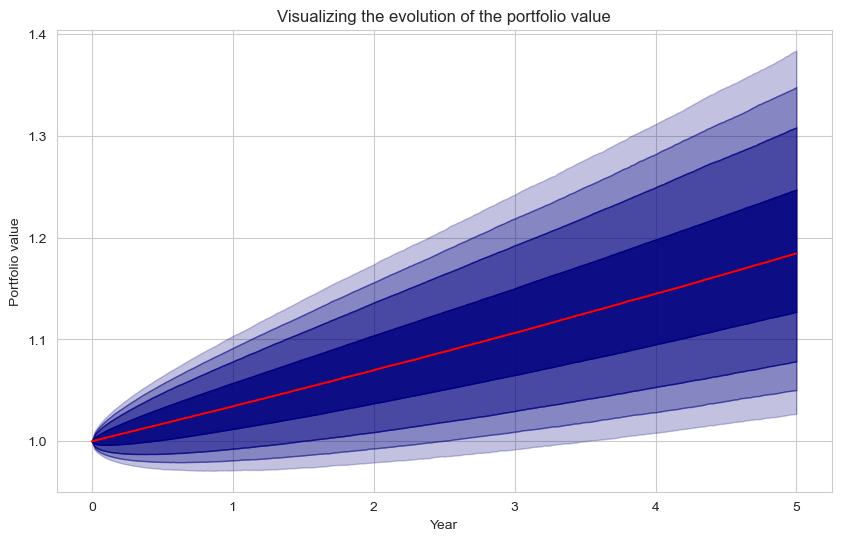

In [63]:
"""
Visualise evolution of portfolio value
"""

percentiles = np.percentile(sim_portfolio_value, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")

ax.set(ylabel='Portfolio value', xlabel="Year", title="Visualizing the evolution of the portfolio value"); 

In [64]:
"""
Evolution in portfolio weights
"""

sim_w = sim_prices * w_mvo_low[None, None, :] / sim_portfolio_value[:, :, None]


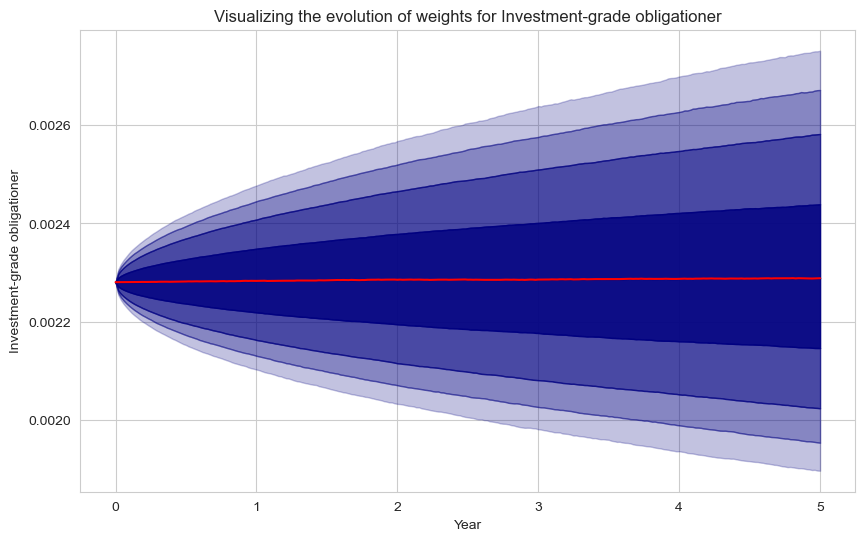

In [66]:
"""
Visualize evolution in portfolio weights
"""

asset_id = 'Investment-grade obligationer'
asset_idx = asset_indices[asset_id]

percentiles = np.percentile(sim_w[:, :, asset_idx], [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")

ax.set(ylabel=asset_id, xlabel="Year", title="Visualizing the evolution of weights for " + asset_id); 

In [67]:
from joblib import Parallel, delayed
# import multiprocessing as mp

In [68]:
"""
Simulate CVaR(5%, 1Y)
"""

horison_in_weeks = 52 * 1
num_sim_to_use = 10_000
sim_cvar = np.zeros((num_sim_to_use, horison_in_weeks + 1))
cvar_time_points = np.arange(0, horison_in_weeks * dt + dt, dt)

#for s in range(num_sim_to_use):
#    for t in range(horison_in_weeks + 1): 
#        sim_cvar[s, t] = -rm.calculate_conditional_value_at_risk(ret_mat_1y @ sim_w[s, t, :], p=0.05)

def compute_simulation_row(s):
    row = np.zeros(horison_in_weeks + 1)
    for t in range(horison_in_weeks + 1):
        # The @ operator performs matrix multiplication
        row[t] = -rm.calculate_conditional_value_at_risk(
            ret_mat_1y @ sim_w[s, t, :], p=0.05
        )
    return row

results = Parallel(n_jobs=-1)(
    delayed(compute_simulation_row)(s) for s in range(num_sim_to_use)
)

sim_cvar = np.array(results)

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [369]:
cvar_time_points = np.arange(0, horison_in_weeks * dt + dt, dt)


In [370]:
cvar_time_points

array([0.        , 0.01923077, 0.03846154, 0.05769231, 0.07692308,
       0.09615385, 0.11538462, 0.13461538, 0.15384615, 0.17307692,
       0.19230769, 0.21153846, 0.23076923, 0.25      , 0.26923077,
       0.28846154, 0.30769231, 0.32692308, 0.34615385, 0.36538462,
       0.38461538, 0.40384615, 0.42307692, 0.44230769, 0.46153846,
       0.48076923, 0.5       , 0.51923077, 0.53846154, 0.55769231,
       0.57692308, 0.59615385, 0.61538462, 0.63461538, 0.65384615,
       0.67307692, 0.69230769, 0.71153846, 0.73076923, 0.75      ,
       0.76923077, 0.78846154, 0.80769231, 0.82692308, 0.84615385,
       0.86538462, 0.88461538, 0.90384615, 0.92307692, 0.94230769,
       0.96153846, 0.98076923, 1.        ])

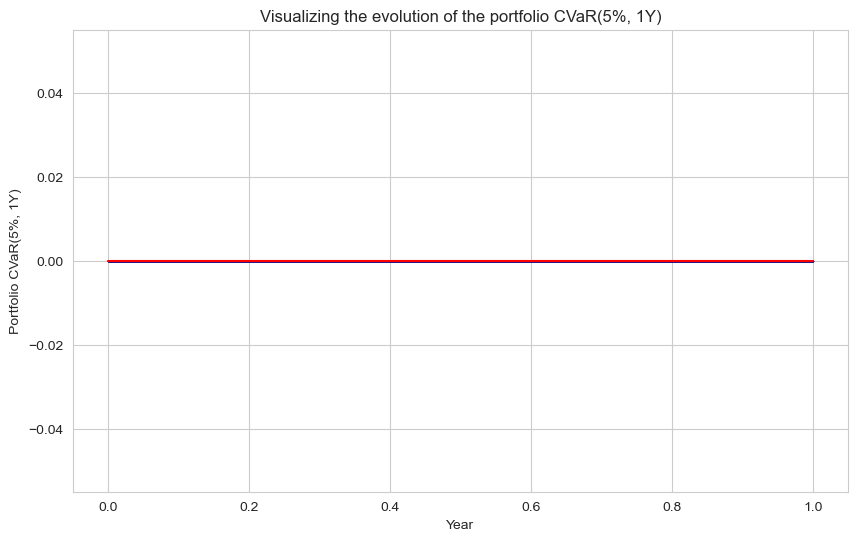

In [69]:
"""
Visualise evolution of portfolio value
"""

percentiles = np.percentile(sim_cvar * 100, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(cvar_time_points, percentiles, ax=ax, color="navy")

ax.set(ylabel='Portfolio CVaR(5%, 1Y)', xlabel="Year", title="Visualizing the evolution of the portfolio CVaR(5%, 1Y)"); 

## Distribution of realized Sharpe ratios, etc. 

In [70]:
"""
Calculate portfolio period return
"""

sim_port_ret = sim_portfolio_value[:, 1:] / sim_portfolio_value[:, :-1] - 1.0

"""
Calculate relevant metrics
"""

sim_port_std = np.std(sim_port_ret, axis=1)
sim_port_ar_ret = np.mean(sim_port_ret, axis=1)
sim_port_sharpe = sim_port_ar_ret / sim_port_std 
sim_port_geo_ret = sim_portfolio_value[:, -1]**(1 / 5.0) - 1.0

<Axes: ylabel='Density'>

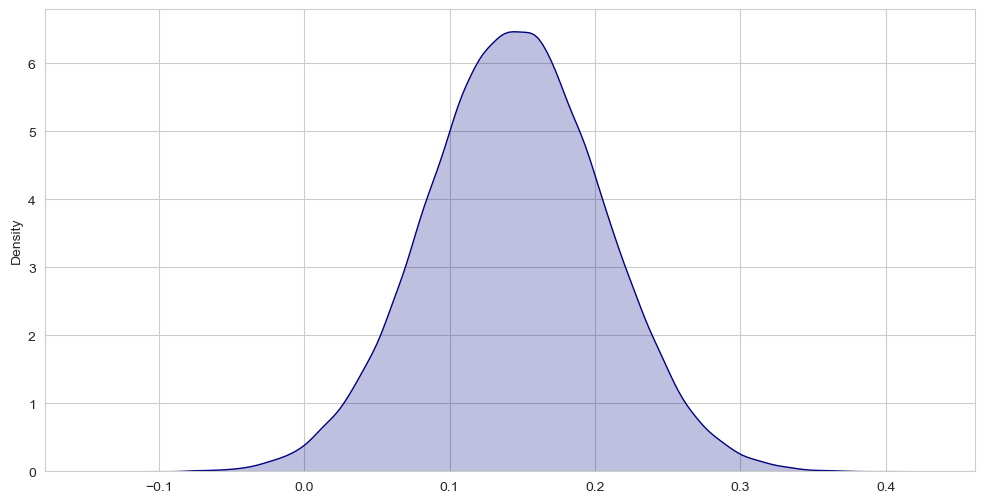

In [71]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(sim_port_sharpe, fill=True, color='navy')

<Axes: ylabel='Density'>

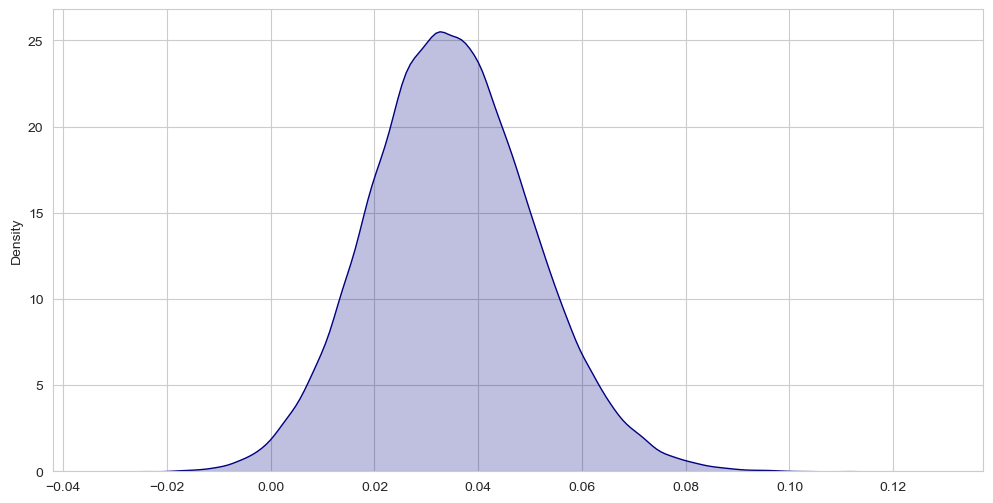

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(sim_port_geo_ret, fill=True, color='navy')

# Problem 2: Adding an investment to existing portfolio

## Simulate equity prices, short rates and bond prices

### Simulate risk drivers

In [73]:
"""
Initialize parameters for simulation
"""

np.random.seed(222)

# equity parameters
sigma = 0.15
mu = 0.06

# short rate parameters
initial_rate = 0.03
kappa = 1.0
theta = 0.03
beta = 0.02
rp = -0.2

# correlation
rho = -0.2

# simulation definition
num_sim = 10_000
dt = 1.0 / 12.0 
horizon = 5.0 
num_time_steps = int(horizon / dt)
time_points = np.arange(0, num_time_steps + 1, 1) * dt

In [74]:
"""
Define functions for simulation
"""

def simulate_vasicek(initial_short_rate: float, kappa: float, theta: float, beta: float, horizon: float, 
                     dt: float=1.0/12, num_sim: int=10000, z_mat=None):
    """
    simulates short rate processes in a vasicek setting until a given horizon 
    
    Parameters
    ----------
    
    initial_short_rate:
        initial short rate
    kappa: 
        speed of mean reversion.
    theta: 
        long term mean of the short rate.
    dt:
        increments in time
    horizon:
        time until maturity/expiry (horizon).
    num_sim:
        number of simulations.
    """
    std_rates = np.sqrt(beta**2 / (2 * kappa) * (1 - np.exp(-2 * kappa * dt)))
    
    num_periods = int(horizon / dt)
    short_rates = np.empty((num_sim, num_periods + 1))
    short_rates[:, 0] = initial_short_rate

    if z_mat is None:
        error_terms = np.random.normal(scale=std_rates, size=(num_sim, num_periods))
    else: 
        error_terms = std_rates * z_mat
    
    for i in range(1, num_periods + 1): 
        
        short_rates[:, i] = theta + (short_rates[:, i - 1] - theta) * np.exp(-kappa * dt) + error_terms[:, i - 1]

    return short_rates


def simulate_risk_drivers(mu: float, sigma: float,
                          initial_rate: float, kappa: float, theta: float, beta: float,
                          rho: float,
                          horizon: float, 
                          dt: float=1.0 / 12,
                          num_sim: int=10_000): 
    
    """
    Function simulating the risky asset and the short rate. 
    """

    # define the number of time steps
    num_time_steps = int(horizon / dt)

    # convert parameters of equity values
    mu_scaled = (mu - 0.5 * sigma**2) * dt
    sigma_scaled = sigma * np.sqrt(dt)

    # define innovation correlation matrix
    z_corr_mat = np.array([[1.0, rho], [rho, 1.0]])

    # simulate innovations
    z_mat = np.random.multivariate_normal(np.zeros(2), z_corr_mat, size=(num_sim, num_time_steps))
    
    # simulate equity prices 
    log_ret = mu_scaled + sigma_scaled * z_mat[:, :, 0]
    
    equity_prices = np.ones((num_sim, num_time_steps + 1))
    equity_prices[:, 1:] = np.exp(np.cumsum(log_ret, axis=1))

    # simulate short rates 
    short_rates = simulate_vasicek(initial_short_rate=initial_rate,
                                   kappa=kappa,
                                   theta=theta,
                                   beta=beta,
                                   horizon=horizon, 
                                   dt=dt,
                                   num_sim=num_sim,
                                   z_mat=z_mat[:, :, 1])
    
    return equity_prices, short_rates



In [75]:
equity_prices[:, :3]

NameError: name 'equity_prices' is not defined

In [77]:
"""
Simulate risk drivers
"""

equity_prices, short_rates = simulate_risk_drivers(mu, sigma,
                                                   initial_rate, kappa, theta, beta,
                                                   rho,
                                                   horizon, 
                                                   dt,
                                                   num_sim)

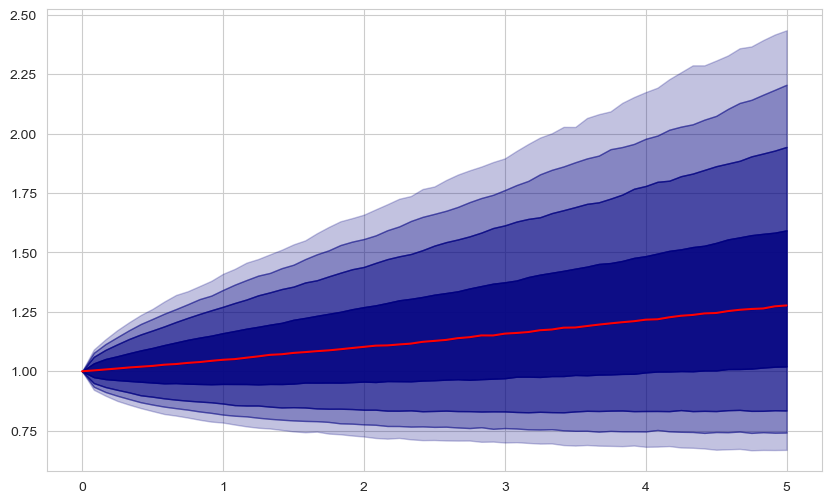

In [78]:
"""
Plot fan chart of short rates
"""
percentiles = np.percentile(equity_prices, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

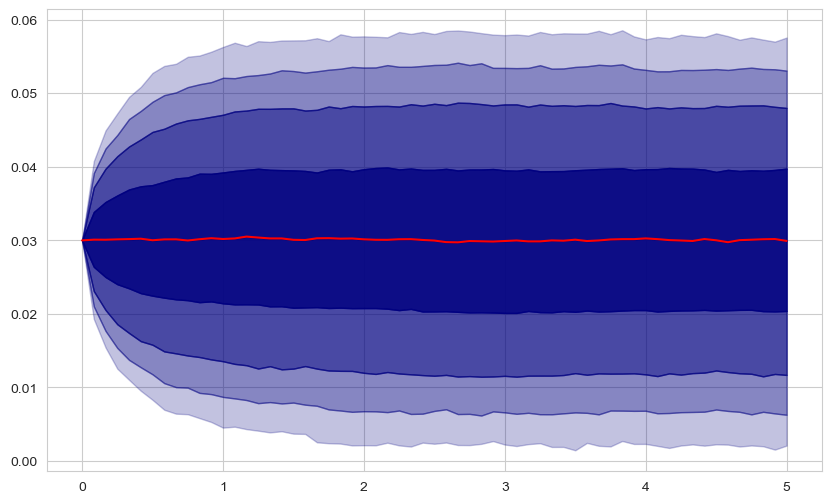

In [79]:
"""
Plot fan chart of short rates
"""
percentiles = np.percentile(short_rates, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

### Simulate Zero Coupon bond prices

In [80]:
"""
Define functions for calculating zero coupon bond prices
"""


def calculate_zero_coupon_yield(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float): 
    
    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)
    
    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2
    
    return (a + b * initial_short_rate) / time_to_maturity

def calculate_zero_coupon_price(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float):
    
    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)
    
    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2
    
    return np.exp(- a - b * initial_short_rate)

In [81]:
"""
Simulate zero coupon bond prices for maturities 10y and 10y - delta t
"""


zcb_10y_mv = np.zeros((num_sim, num_time_steps + 1))
zcb_10y_minus_delta_t = np.zeros((num_sim, num_time_steps + 1))

for i, t in enumerate(time_points):
    zcb_10y_mv[:, i] = calculate_zero_coupon_price(10.0, short_rates[:, i], kappa, theta, beta, rp)
    zcb_10y_minus_delta_t[:, i] = calculate_zero_coupon_price(10.0 - dt, short_rates[:, i], kappa, theta, beta, rp)

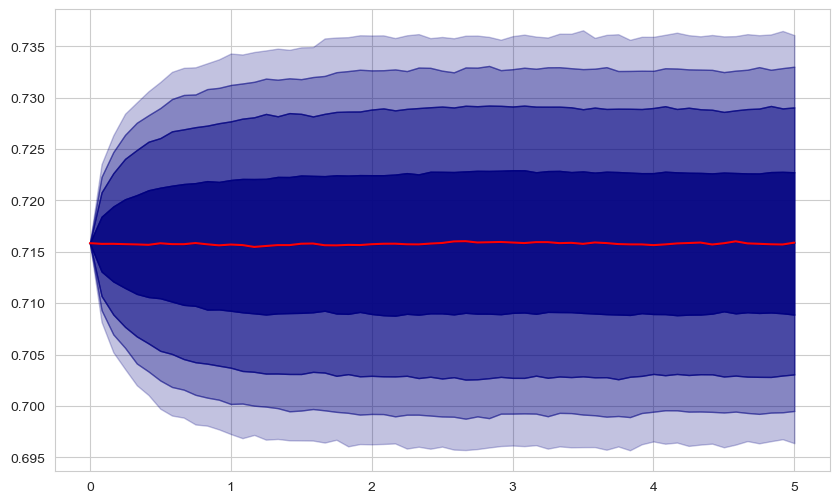

In [82]:
"""
Plot fan chart of zero coupon bond prices
"""
percentiles = np.percentile(zcb_10y_mv, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

### Calculate portfolio value

In [83]:
init_wealth = 100e6
eq_w = 0.6
zcb_w = 0.4

In [84]:
"""
Calculate return of bond and equity
"""
eq_ret = equity_prices[:, 1:] / equity_prices[:, :-1] - 1.0
zcb_ret = zcb_10y_minus_delta_t[:, 1:] / zcb_10y_mv[:, :-1] - 1.0
port_ret = eq_w * eq_ret + zcb_w * zcb_ret

In [85]:
eq_ret

array([[-0.05279574,  0.01622969,  0.05069633, ...,  0.00456282,
        -0.00935075,  0.07464519],
       [-0.03538009,  0.02035855,  0.00784493, ..., -0.05128982,
         0.0281134 , -0.00353947],
       [ 0.09938712, -0.03158713,  0.00213367, ...,  0.01168047,
         0.02820332,  0.04671484],
       ...,
       [-0.04362083,  0.00371163, -0.03291363, ..., -0.0857294 ,
        -0.03975048,  0.02914806],
       [-0.00302576,  0.00960696,  0.03056992, ...,  0.03762665,
         0.01763296, -0.00207713],
       [-0.06104576,  0.04732335, -0.05531583, ...,  0.00465978,
         0.09568928, -0.01878175]])

In [86]:
"""
Calculate portfolio value
"""

port_value = np.c_[init_wealth * np.ones(num_sim), init_wealth * np.cumprod( 1 + port_ret, axis=1)]

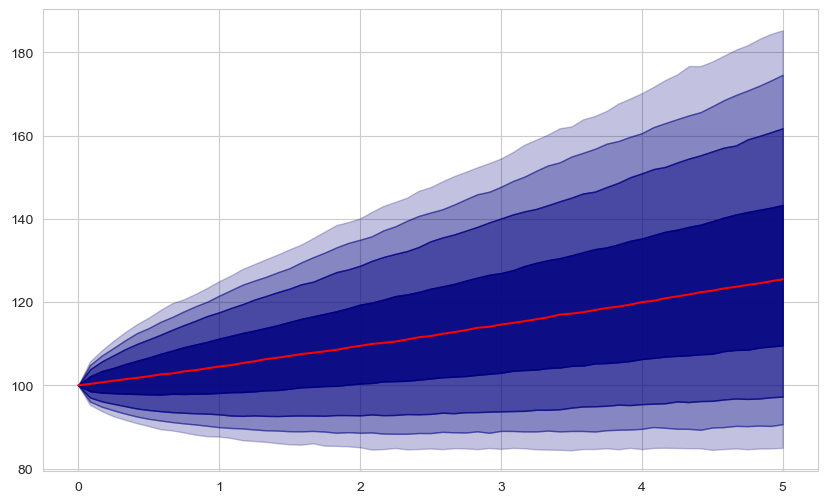

In [87]:
"""
Plot fan chart of zero coupon bond prices
"""
percentiles = np.percentile(port_value / 1e6, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

## Two investment strategies

In [88]:
"""
Define functions for calculating zero coupon bond prices with spread
"""


def calculate_zero_coupon_yield_with_spread(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float,
                                spread: float): 
    
    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)
    
    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2
    
    return (a + b * initial_short_rate) / time_to_maturity + spread

def calculate_zero_coupon_price_with_spread(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float,
                                spread):
    
    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)
    
    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2
    
    return np.exp(- a - b * initial_short_rate - spread * time_to_maturity)

### Expected cash flows at time zero 

The expected value of the equity value at time $t$ is equal to $V_{Eq, t} e^{(T - t) \mu}$. Thus, we have the cash flow as written below.

In [91]:
"""
Define initial expected cash flows
"""

cf_time_points=np.array([1.0, 2.0, 3.0, 4.0, 5.0])
expected_flows_1 = np.array([10.0, 10.0, 10.0, 10.0, 10.0])
expected_flows_2 = np.array([10.0, 10.0, 10.0, 10.0, 10.0])

init_expected_cash_flow_1 = CashFlow(time_points=np.array([1.0, 2.0, 3.0, 4.0, 5.0]), flows=expected_flows_1)
init_expected_cash_flow_2 = CashFlow(time_points=np.array([1.0, 2.0, 3.0, 4.0, 5.0]), flows=expected_flows_2)

In [93]:
"""
Present value
"""

spread = 300 / 100 / 100

discount_factors_t0 = calculate_zero_coupon_price_with_spread(cf_time_points, short_rates[0, 0], kappa, theta, beta, rp, spread)

mv_1 = discount_factors_t0 @ init_expected_flows_1
mv_2 = discount_factors_t0 @ init_expected_flows_2

ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

In [477]:
mv_1

41.59296589002812

In [478]:
mv_2

41.59296589002812

In [479]:
"""
Internal rate of return
"""

irr_1 = init_expected_cash_flow_1.internal_rate_of_return(market_value=mv_1)
irr_2 = init_expected_cash_flow_2.internal_rate_of_return(market_value=mv_2)

In [480]:
irr_1

0.062672133507931

In [481]:
irr_2

0.062672133507931

### Realized Cash Flows

In [482]:
week_idx = (cf_time_points / dt).astype(int)

In [494]:
realized_flows_1 = 10 + 5 * (equity_prices[:, week_idx] - np.exp(mu * cf_time_points)[None, :])
realized_flows_2 = 10 - 2.5 * (equity_prices[:, week_idx] - np.exp(mu * cf_time_points)[None, :])

In [495]:
realized_flows_1

array([[ 8.3310726 ,  8.24582897,  9.40347893,  8.64926976,  7.76423822],
       [10.97492284, 10.07138593, 10.80144661, 10.84651196,  9.61645971],
       [ 8.64217059,  7.75699673,  7.14647254,  7.11895964,  6.26877285],
       ...,
       [10.61835384, 10.32642912, 11.96011858, 13.97690971, 13.78107997],
       [ 9.71363807,  9.85971743, 10.55353669,  9.6718323 , 11.48910047],
       [10.07939102,  8.72977472,  8.66197218,  8.72635793,  8.11234531]])

In [498]:
realized_irr_1 = []
realized_irr_2 = []

for s in range(num_sim): 
    
    cf_temp1 = CashFlow(time_points=cf_time_points, flows=realized_flows_1[s, :])
    cf_temp2 = CashFlow(time_points=cf_time_points, flows=realized_flows_2[s, :])
    
    realized_irr_1.append(cf_temp1.internal_rate_of_return(market_value=mv_1, lower_limit= -2.0, upper_limit= 2.0))
    realized_irr_2.append(cf_temp2.internal_rate_of_return(market_value=mv_2, lower_limit= -2.0, upper_limit= 2.0))

realized_irr_1 = np.array(realized_irr_1)
realized_irr_2 = np.array(realized_irr_2)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

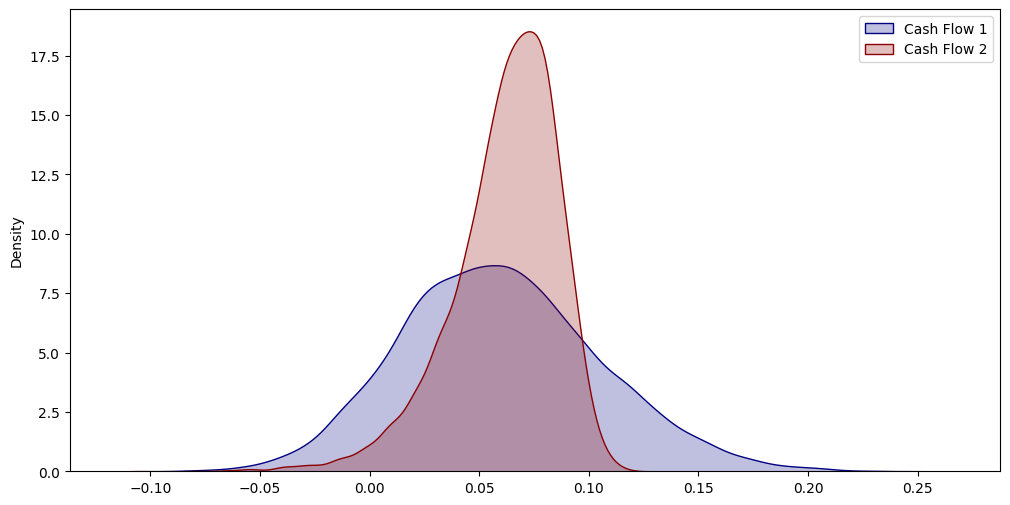

In [505]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(realized_irr_1, fill=True, color='navy', ax=ax, label="Cash Flow 1")
sns.kdeplot(realized_irr_2, fill=True, color='darkred', ax=ax, label="Cash Flow 2")

ax.legend();

### Portfolio effect

In [507]:

realized_mv_1 = np.zeros((num_sim, len(time_points)))
realized_mv_1[:, 0] = mv_1

realized_mv_2 = np.zeros((num_sim, len(time_points)))
realized_mv_2[:, 0] = mv_1

In [538]:
def calculate_zero_coupon_price_with_spread_vectorized(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: Union[float, np.ndarray],
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float,
                                spread):
    
    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)
    
    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2
    
    return np.exp(- a - b * initial_short_rate[:, None] - spread * time_to_maturity)

In [548]:
"""
Calculate market value of future expected cash flows
"""

expectation_equity = np.exp(mu * cf_time_points)

for i, t in enumerate(time_points[:-1]): 
    # indicator to select cash flow and time points
    adj_cf_time_points = (cf_time_points - t)
    indicator = adj_cf_time_points > 0

    # adjusted time points
    adj_cf_time_points = adj_cf_time_points[indicator]

    # relevant initial equity expectations
    adj_init_expectation_equity = expectation_equity[indicator]
    
    # expected future cash flow
    expected_future_cash_flow_1 = 10 + 5 * (np.outer(equity_prices[:, i], np.exp(mu * adj_cf_time_points)) - adj_init_expectation_equity[None, :])
    expected_future_cash_flow_2 = 10 - 2.5 * (np.outer(equity_prices[:, i], np.exp(mu * adj_cf_time_points)) - adj_init_expectation_equity[None, :])
        
    # calculate discount vectors
    discounter_vectors = calculate_zero_coupon_price_with_spread_vectorized(adj_cf_time_points, short_rates[:, i], kappa, theta, beta, rp, spread)

    # calculate market values
    realized_mv_1[:, i] = np.sum(discounter_vectors * expected_future_cash_flow_1, axis=1)
    realized_mv_2[:, i] = np.sum(discounter_vectors * expected_future_cash_flow_2, axis=1)

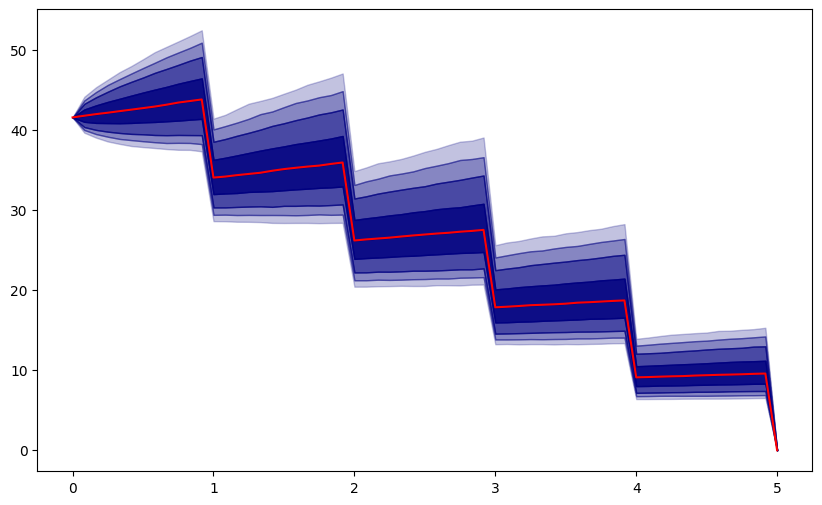

In [550]:
"""
Plot fan chart of cash flow market values
"""
percentiles = np.percentile(realized_mv_1, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

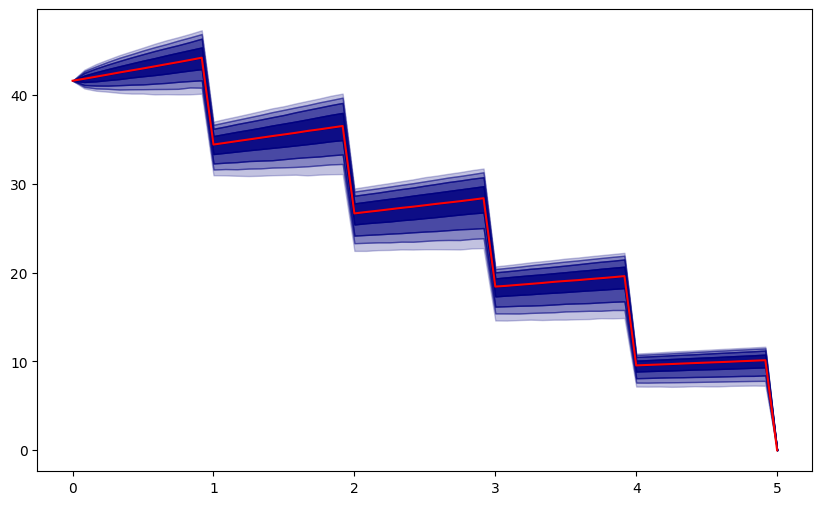

In [551]:
"""
Plot fan chart of cash flow market values
"""
percentiles = np.percentile(realized_mv_2, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

In [ ]:
"""
Simulate value of portfolio with the two different investments
"""

In [561]:
port_value_1 = np.zeros((num_sim, len(time_points)))
port_value_1[:, 0] = init_wealth / 1e6

asset_value_1 = np.zeros((num_sim, len(time_points)))
asset_value_1[:, 0] = port_value_1[:, 0] - realized_mv_1[:, 0]

port_value_2 = np.zeros((num_sim, len(time_points)))
port_value_2[:, 0] = init_wealth / 1e6

asset_value_2 = np.zeros((num_sim, len(time_points)))
asset_value_2[:, 0] = port_value_2[:, 0] - realized_mv_2[:, 0]

idx = 0
for i, t in enumerate(time_points[1:], start=1): 

    asset_value_1[:, i] = asset_value_1[:, i - 1] * (1 + port_ret[:, i - 1])
    asset_value_2[:, i] = asset_value_2[:, i - 1] * (1 + port_ret[:, i - 1])

    if i in week_idx: 

        asset_value_1[:, i] += realized_flows_1[:, idx]
        asset_value_2[:, i] += realized_flows_2[:, idx]

        idx += 1

    port_value_1[:, i] = asset_value_1[:, i] + realized_mv_1[:, i]
    port_value_2[:, i] = asset_value_2[:, i] + realized_mv_2[:, i]
    

In [566]:
port_value_scaled = port_value / 1e6

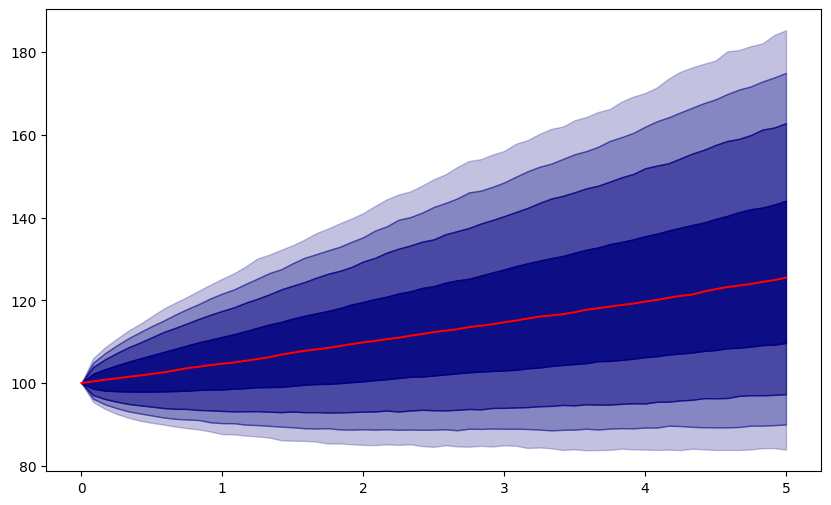

In [570]:
"""
Plot fan chart of initial portfolio
"""
percentiles = np.percentile(port_value_scaled, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

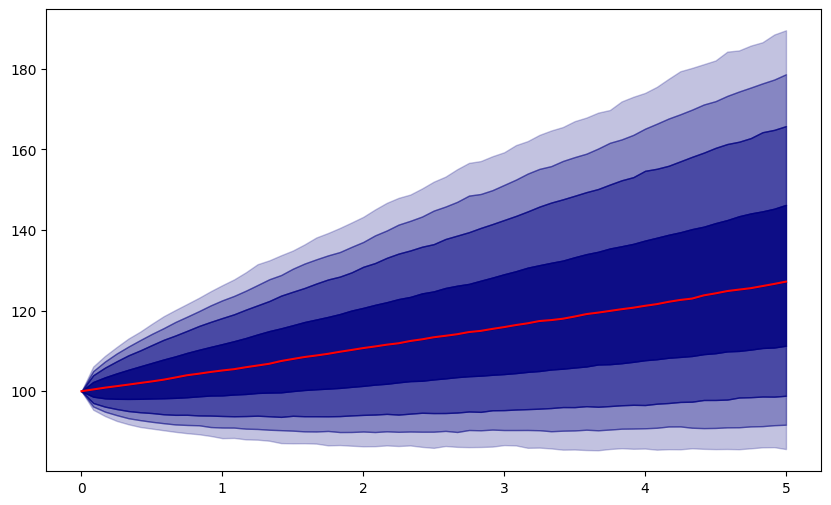

In [562]:
"""
Plot fan chart of portfolio with investment 1
"""
percentiles = np.percentile(port_value_1, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

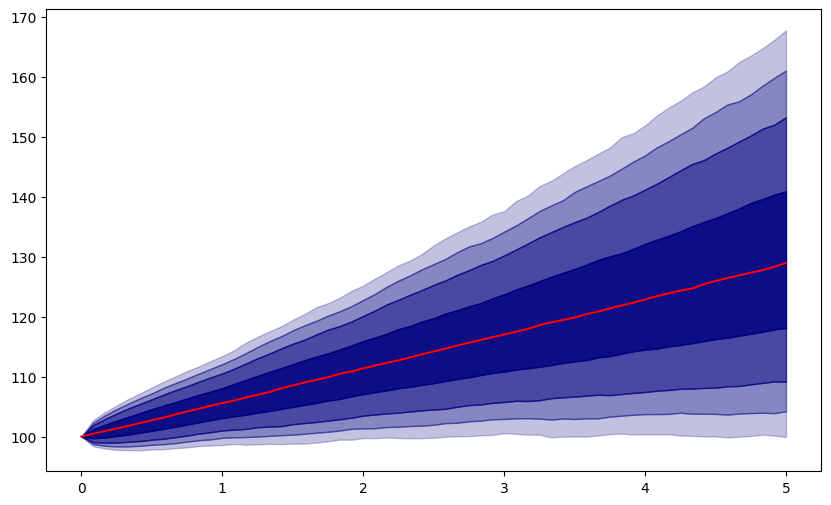

In [563]:
"""
Plot fan chart of portfolio with investment 2
"""
percentiles = np.percentile(port_value_2, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

### Evaluation

In [568]:
df_eval = pd.DataFrame(index=['Expectation', 'Std.', 'CVaR'], columns=['Initial portfolio', 'Investment 1', 'Investment 2'], 
                       data = np.array([[np.mean(port_value_scaled[:, -1]), np.mean(port_value_1[:, -1]), np.mean(port_value_2[:, -1])], 
                                        [np.std(port_value_scaled[:, -1]), np.std(port_value_1[:, -1]), np.std(port_value_2[:, -1])], 
                                        [rm.calculate_conditional_value_at_risk(port_value_scaled[:, -1], p=0.05), rm.calculate_conditional_value_at_risk(port_value_1[:, -1], p=0.05), rm.calculate_conditional_value_at_risk(port_value_2[:, -1], p=0.05)]]))

In [569]:
df_eval

,Initial portfolio,Investment 1,Investment 2
Expectation,128.192924,130.260159,130.211773
Std.,26.085723,26.763238,17.292039
CVaR,82.699599,84.565920,98.818144
